# German Credit Risk Classification — Logistic Regression
Dataset: `German_Credit-1.xlsx` | Goal: Predict `Risk` (good / bad credit)

## Objective: Predict credit risk (good/bad) to aid lending decisions.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,
)

# Show all columns and up to 200 rows in DataFrames
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

warnings.filterwarnings("ignore")

## 2. Load Data

In [2]:
# Load the German Credit dataset from Excel
data = pd.read_excel(r"C:\Users\DELL\Downloads\German_Credit-1.xlsx")

## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Inspection

In [3]:
# Preview first rows to understand structure
print("First 5 rows:")
data.head()

First 5 rows:


,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,little,little,1169,6,0,radio/TV
1,22,female,little,moderate,5951,48,1,radio/TV
2,49,male,little,little,2096,12,0,education
3,45,male,little,little,7882,42,0,furniture/equipment
4,53,male,little,little,4870,24,1,car


In [4]:
data.tail()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
995,31,female,little,little,1736,12,0,furniture/equipment
996,40,male,little,little,3857,30,0,car
997,38,male,little,little,804,12,0,radio/TV
998,23,male,little,little,1845,45,1,radio/TV
999,27,male,moderate,moderate,4576,45,0,car


In [5]:
print("Shape:", data.shape)

Shape: (1000, 8)


In [6]:
# Column data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Saving accounts   1000 non-null   object
 3   Checking account  1000 non-null   object
 4   Credit amount     1000 non-null   int64 
 5   Duration          1000 non-null   int64 
 6   Risk              1000 non-null   int64 
 7   Purpose           1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


In [7]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [8]:
print("Missing values:")
data.isnull().sum()

Missing values:


Age                 0
Sex                 0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Risk                0
Purpose             0
dtype: int64

In [9]:
# Statistical summary of numeric features
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Risk,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0


### 3.2 Categorical Feature Distributions

In [10]:
# Value counts for each categorical column
cat_col = ["Sex", "Saving accounts", "Checking account", "Purpose", "Risk"]

for column in cat_col:
    print(f"--- {column} ---")
    print(data[column].value_counts())
    print("-" * 40)

--- Sex ---
Sex
male      690
female    310
Name: count, dtype: int64
----------------------------------------
--- Saving accounts ---
Saving accounts
little        786
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64
----------------------------------------
--- Checking account ---
Checking account
moderate    472
little      465
rich         63
Name: count, dtype: int64
----------------------------------------
--- Purpose ---
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64
----------------------------------------
--- Risk ---
Risk
0    700
1    300
Name: count, dtype: int64
----------------------------------------


### 3.3 Numeric Feature Distributions

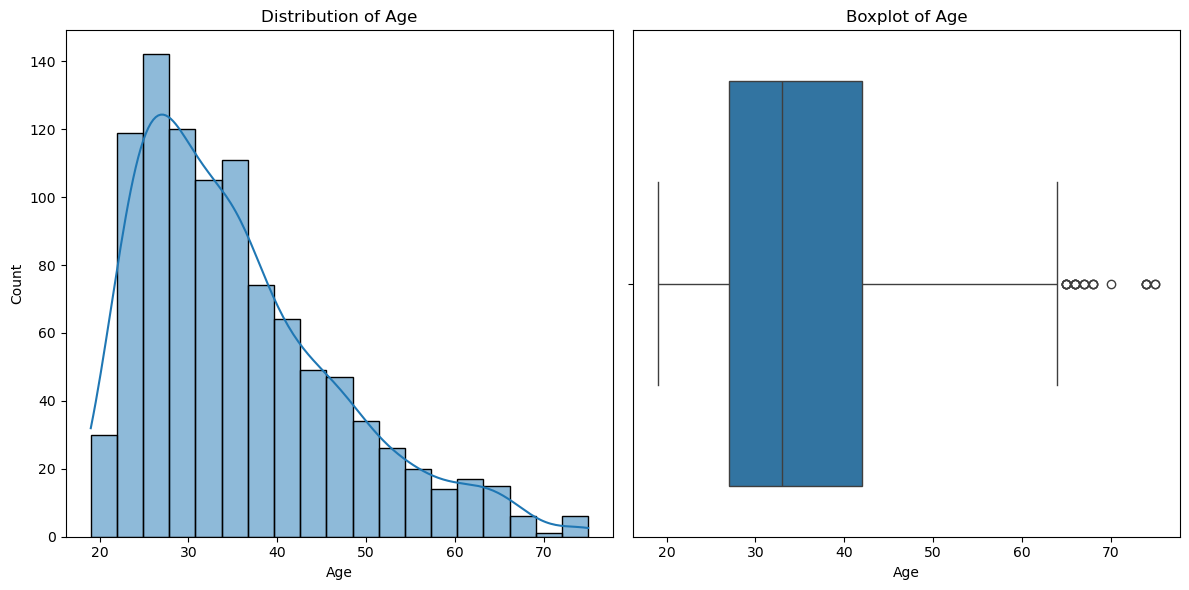

In [11]:
# Distribution and boxplot for Age
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data["Age"], kde=True)
plt.title("Distribution of Age")

plt.subplot(1, 2, 2)
sns.boxplot(x=data["Age"])
plt.title("Boxplot of Age")

plt.tight_layout()
plt.show()

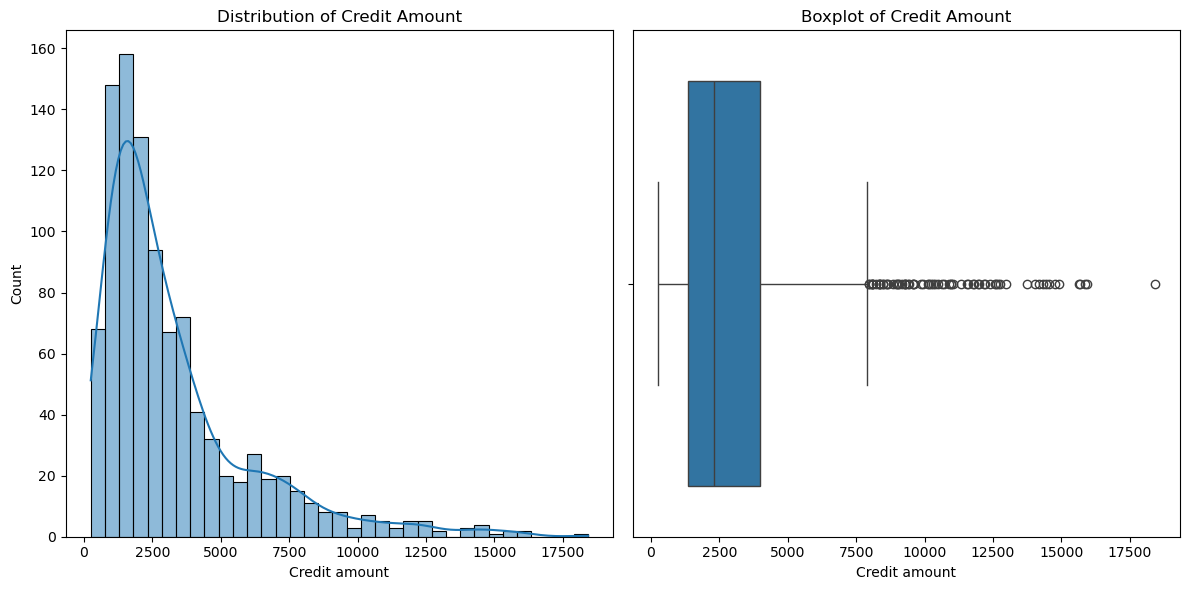

In [12]:
# Distribution and boxplot for Credit Amount
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data["Credit amount"], kde=True)
plt.title("Distribution of Credit Amount")

plt.subplot(1, 2, 2)
sns.boxplot(x=data["Credit amount"])
plt.title("Boxplot of Credit Amount")

plt.tight_layout()
plt.show()

### 3.4 Target Variable & Categorical Plots

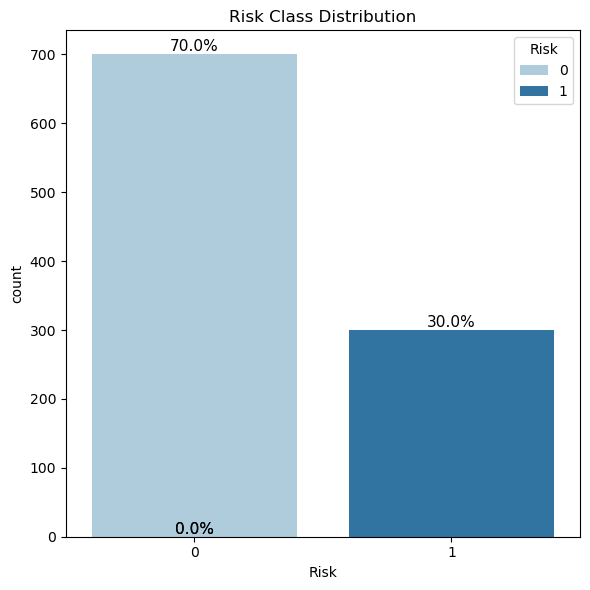

In [13]:
# Risk class distribution — check for class imbalance
plt.figure(figsize=(6, 6))
total = len(data["Risk"])
ax = sns.countplot(x="Risk", data=data, hue="Risk", palette="Paired")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{100 * height / total:.1f}%",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=11)

plt.title("Risk Class Distribution")
plt.tight_layout()
plt.show()

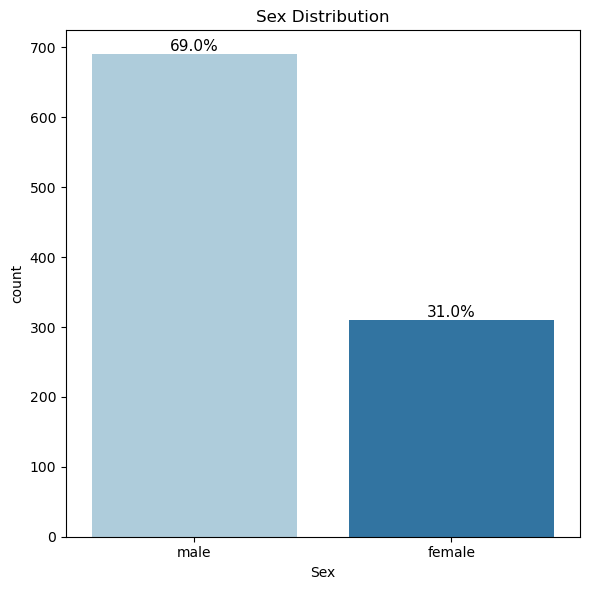

In [14]:
# Gender distribution
plt.figure(figsize=(6, 6))
total = len(data["Sex"])
ax = sns.countplot(x="Sex", data=data, hue="Sex", palette="Paired")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{100 * height / total:.1f}%",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=11)

plt.title("Sex Distribution")
plt.tight_layout()
plt.show()

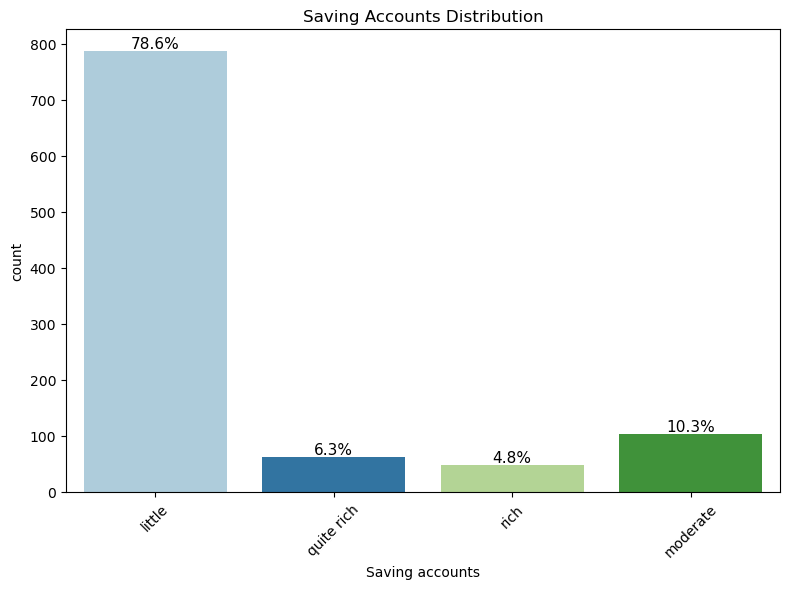

In [15]:
# Saving accounts distribution
plt.figure(figsize=(8, 6))
total = len(data["Saving accounts"])
ax = sns.countplot(x="Saving accounts", data=data, hue="Saving accounts", palette="Paired")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{100 * height / total:.1f}%",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=11)

plt.title("Saving Accounts Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.5 Correlation & Pairplot

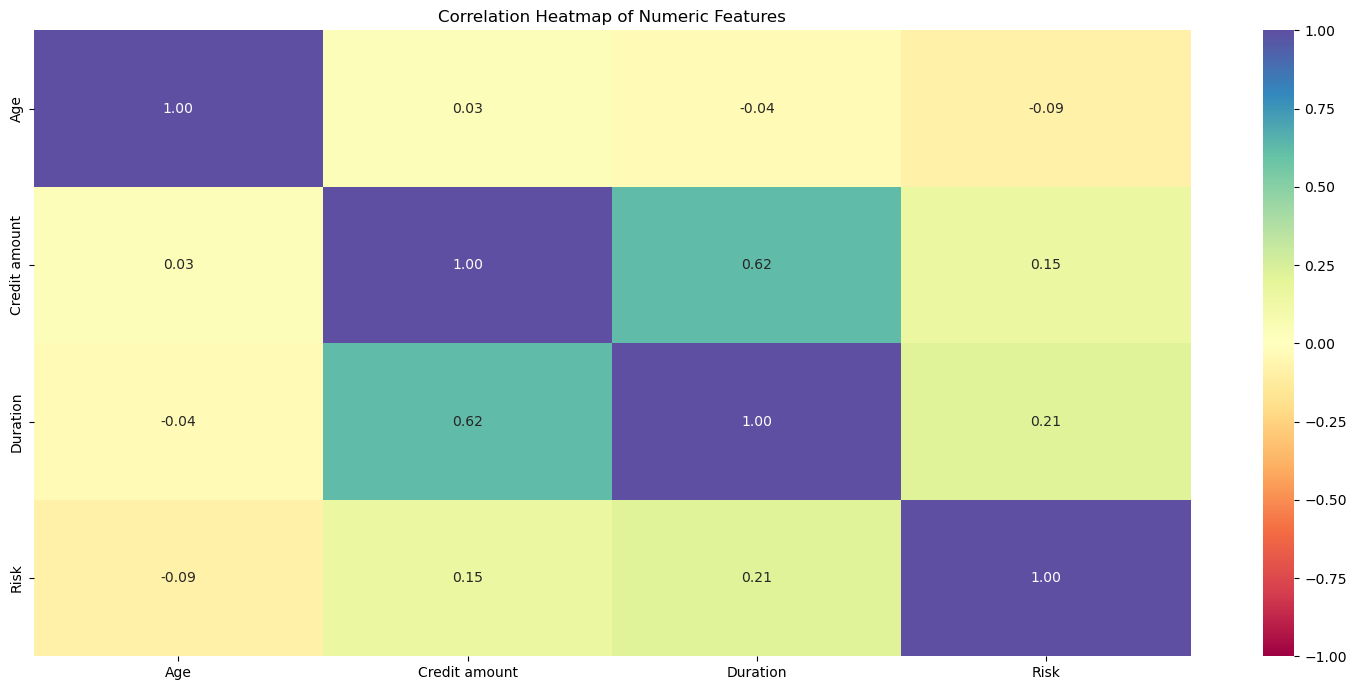

In [16]:
# Correlation heatmap — shows linear relationships between numeric features
plt.figure(figsize=(15, 7))
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

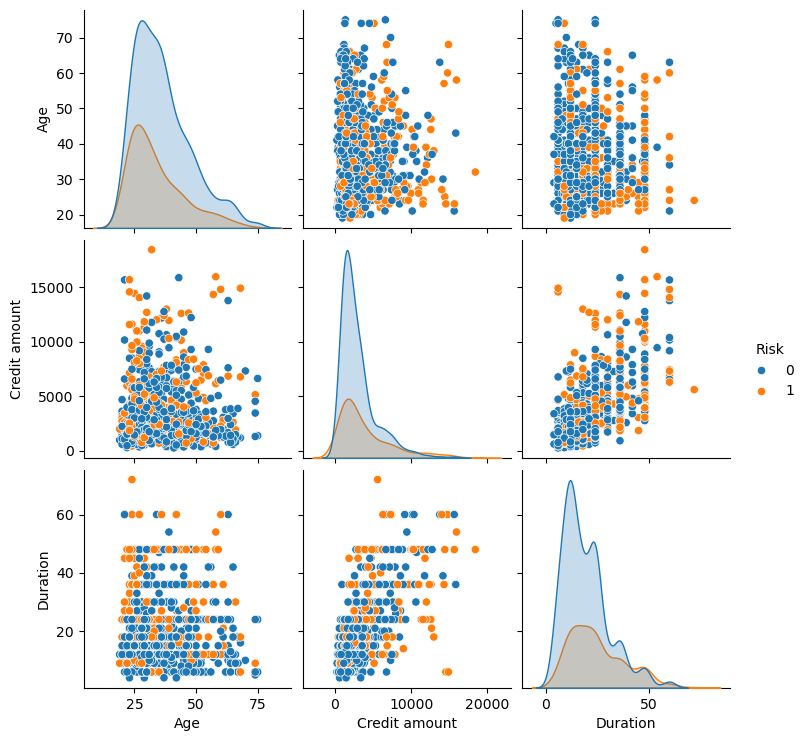

In [17]:
# Pairplot coloured by Risk — reveals feature separability by class
sns.pairplot(data, hue="Risk")
plt.show()

### 3.6 Bivariate Analysis — Credit Amount & Duration vs Risk

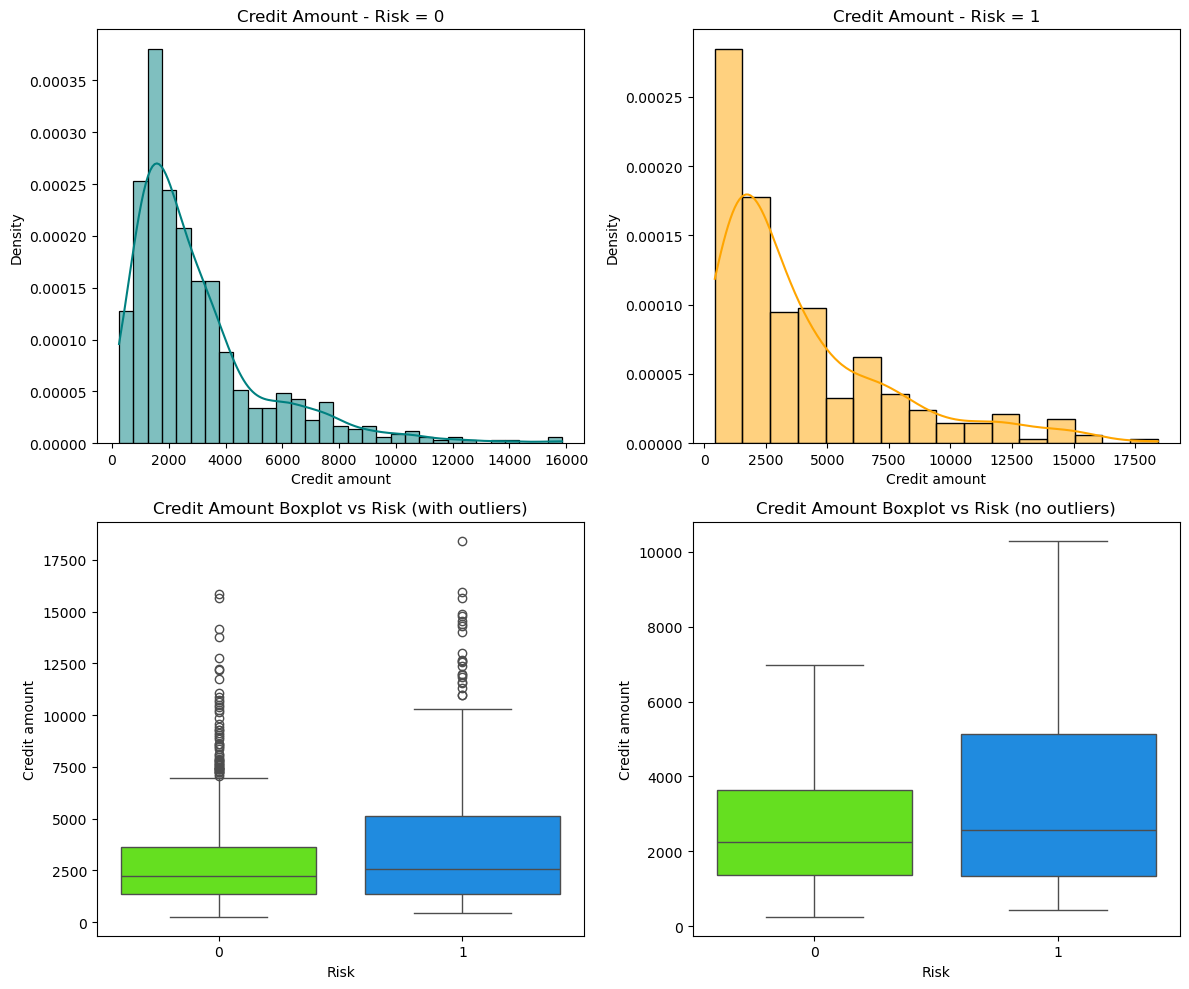

In [18]:
# Credit Amount distribution split by Risk class
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
target_vals = data["Risk"].unique()

sns.histplot(data[data["Risk"] == target_vals[0]], x="Credit amount",
             kde=True, color="teal", stat="density", ax=axs[0, 0])
axs[0, 0].set_title(f"Credit Amount - Risk = {target_vals[0]}")

sns.histplot(data[data["Risk"] == target_vals[1]], x="Credit amount",
             kde=True, color="orange", stat="density", ax=axs[0, 1])
axs[0, 1].set_title(f"Credit Amount - Risk = {target_vals[1]}")

sns.boxplot(data=data, x="Risk", y="Credit amount",
            palette="gist_rainbow", ax=axs[1, 0])
axs[1, 0].set_title("Credit Amount Boxplot vs Risk (with outliers)")

sns.boxplot(data=data, x="Risk", y="Credit amount",
            showfliers=False, palette="gist_rainbow", ax=axs[1, 1])
axs[1, 1].set_title("Credit Amount Boxplot vs Risk (no outliers)")

plt.tight_layout()
plt.show()

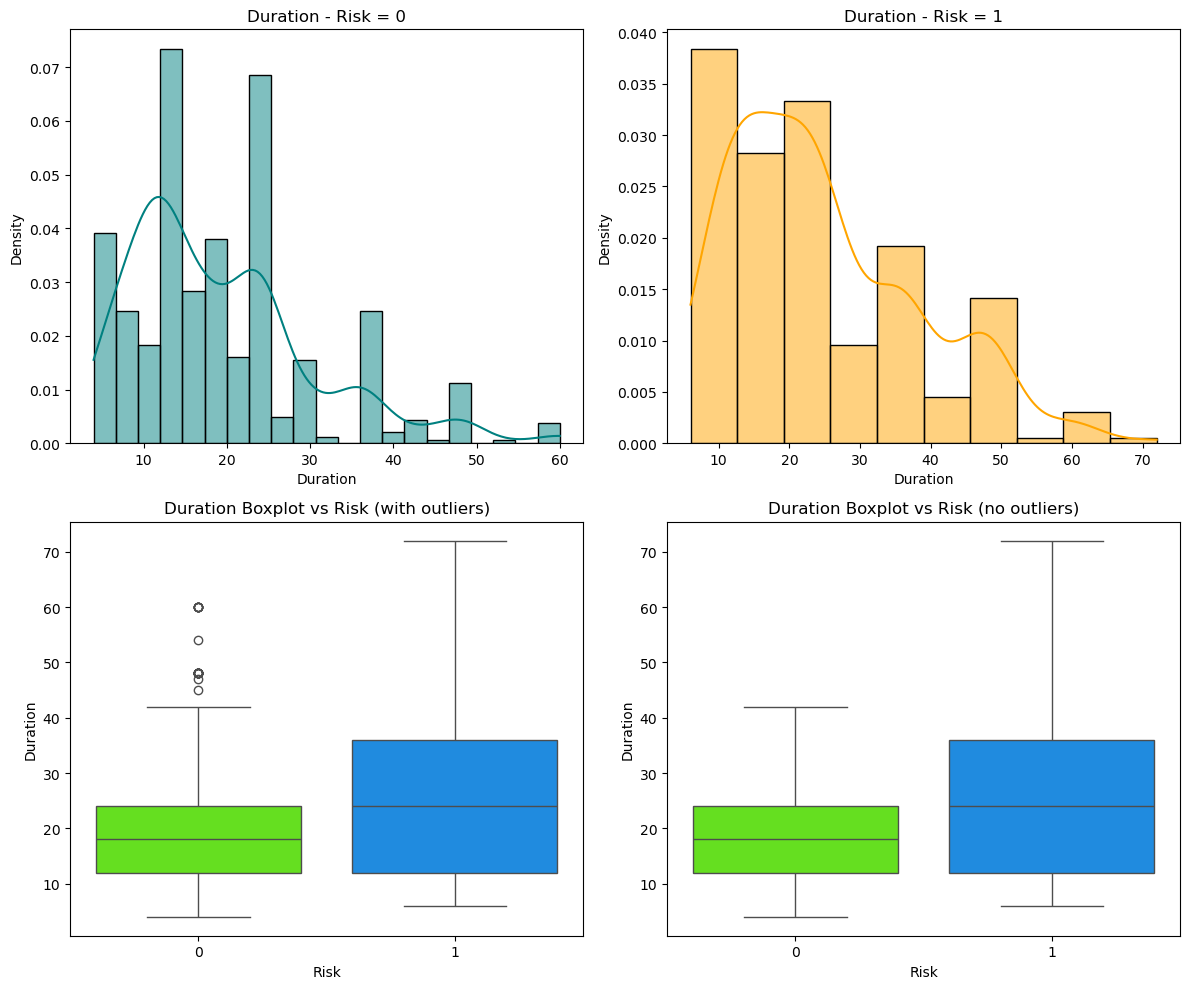

In [19]:
# Loan Duration distribution split by Risk class
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(data[data["Risk"] == target_vals[0]], x="Duration",
             kde=True, color="teal", stat="density", ax=axs[0, 0])
axs[0, 0].set_title(f"Duration - Risk = {target_vals[0]}")

sns.histplot(data[data["Risk"] == target_vals[1]], x="Duration",
             kde=True, color="orange", stat="density", ax=axs[0, 1])
axs[0, 1].set_title(f"Duration - Risk = {target_vals[1]}")

sns.boxplot(data=data, x="Risk", y="Duration",
            palette="gist_rainbow", ax=axs[1, 0])
axs[1, 0].set_title("Duration Boxplot vs Risk (with outliers)")

sns.boxplot(data=data, x="Risk", y="Duration",
            showfliers=False, palette="gist_rainbow", ax=axs[1, 1])
axs[1, 1].set_title("Duration Boxplot vs Risk (no outliers)")

plt.tight_layout()
plt.show()

Risk                   0    1   All
Purpose                            
All                  700  300  1000
car                  231  106   337
radio/TV             218   62   280
furniture/equipment  123   58   181
business              63   34    97
education             36   23    59
repairs               14    8    22
vacation/others        7    5    12
domestic appliances    8    4    12
------------------------------------------------------------------------------------------------------------------------


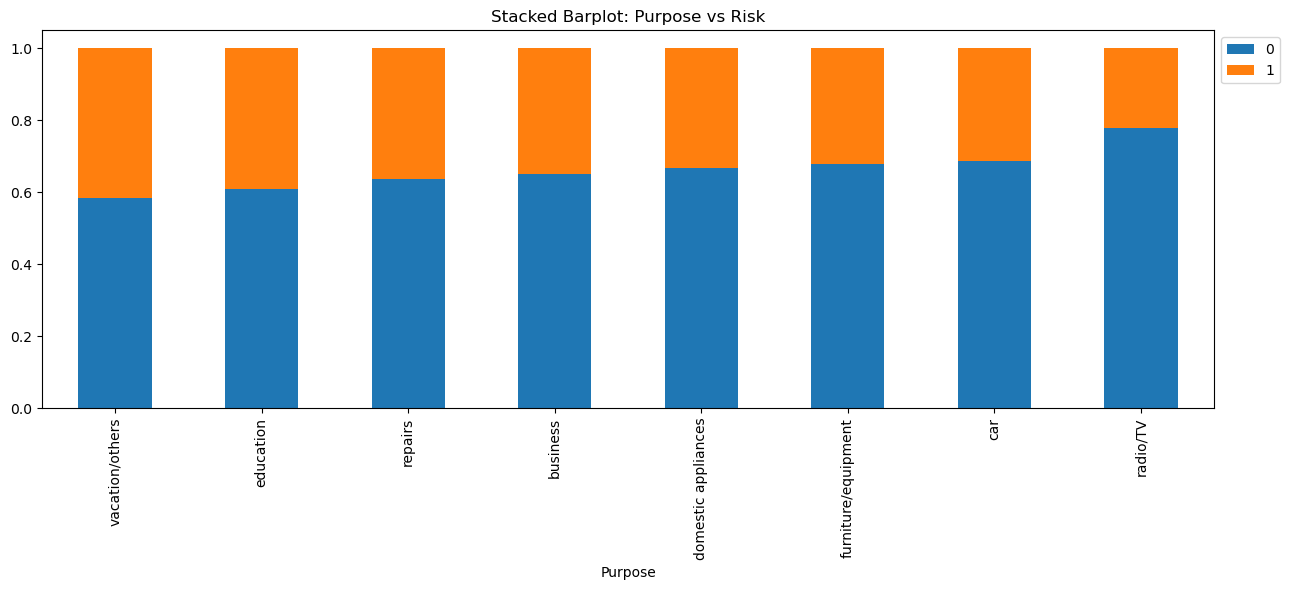

In [20]:
# Stacked bar chart: Purpose vs Risk — shows which loan purposes carry more risk
count = data["Purpose"].nunique()
sorter = data["Risk"].value_counts().index[-1]

tab1 = pd.crosstab(data["Purpose"], data["Risk"], margins=True)          .sort_values(by=sorter, ascending=False)
print(tab1)
print("-" * 120)

tab = pd.crosstab(data["Purpose"], data["Risk"], normalize="index")         .sort_values(by=sorter, ascending=False)

tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6))
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.title("Stacked Barplot: Purpose vs Risk")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [21]:
# Convert Duration from months to years for easier interpretation
data["Duration"] = data["Duration"] / 12
print("Duration now in years. Sample values:")
print(data["Duration"].head())

Duration now in years. Sample values:
0    0.5
1    4.0
2    1.0
3    3.5
4    2.0
Name: Duration, dtype: float64


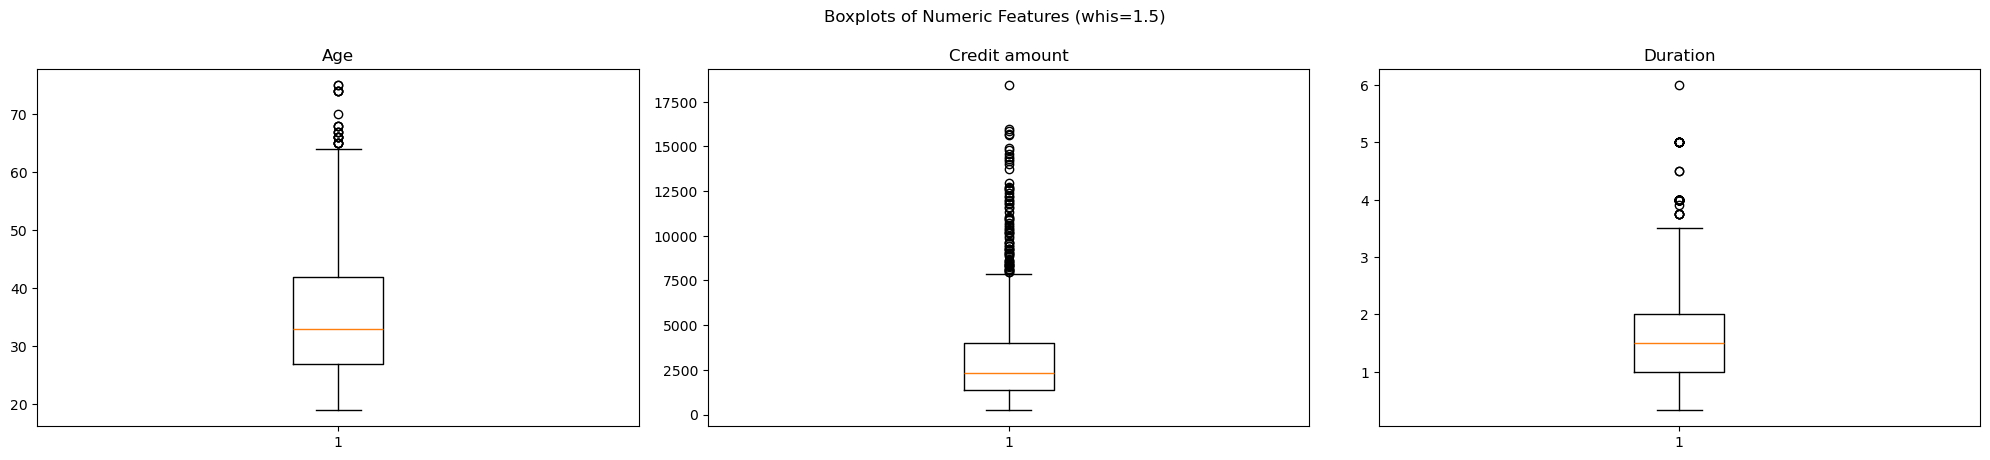

In [22]:
# Outlier visualisation for all numeric features using boxplots
numerical_col = data.select_dtypes(include=np.number).columns.tolist()
numerical_col.remove("Risk")  # Exclude target variable

plt.figure(figsize=(20, 12))
for i, variable in enumerate(numerical_col):
    plt.subplot(3, 3, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.title(variable)
    plt.tight_layout()
plt.suptitle("Boxplots of Numeric Features (whis=1.5)", y=1.02)
plt.show()

In [23]:
# Separate features (X) and target (y)
X = data.drop("Risk", axis=1)
Y = data["Risk"]

# One-hot encode categorical columns; drop_first=True avoids multicollinearity
X = pd.get_dummies(X, drop_first=True)

# Split into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1
)

print("Training set shape :", X_train.shape)
print("Test set shape     :", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))

Training set shape : (700, 16)
Test set shape     : (300, 16)

Class distribution in training set:
Risk
0    0.694286
1    0.305714
Name: proportion, dtype: float64

Class distribution in test set:
Risk
0    0.713333
1    0.286667
Name: proportion, dtype: float64


## 5. Model Building — Logistic Regression

In [24]:
# Helper: compute classification metrics at a given decision threshold
def model_performance_classification_sklearn(model, X, y, threshold=0.5):
    pred_proba = model.predict_proba(X)[:, 1]
    pred = (pred_proba >= threshold).astype(int)
    pos_label = y.unique()[0]
    return pd.DataFrame({
        "Accuracy" : [accuracy_score(y, pred)],
        "Recall"   : [recall_score(y, pred, pos_label=pos_label)],
        "Precision": [precision_score(y, pred, pos_label=pos_label)],
        "F1 Score" : [f1_score(y, pred, pos_label=pos_label)],
    })

In [25]:
# Helper: plot a labelled confusion matrix heatmap
def plot_confusion_matrix(model, X, y, threshold=0.5, title="Confusion Matrix"):
    pred_proba = model.predict_proba(X)[:, 1]
    y_pred = np.round(pred_proba >= threshold)
    cm = confusion_matrix(y, y_pred)
    labels = np.asarray(
        [[f"{item:.0f}\n{item / cm.sum():.2%}" for item in row] for row in cm]
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues")
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

In [26]:
# Train Logistic Regression with newton-cg solver
# (more stable for smaller datasets than the default lbfgs)
model = LogisticRegression(solver="newton-cg", random_state=1)
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 6. Model Evaluation

### 6.1 Default Threshold (0.5)

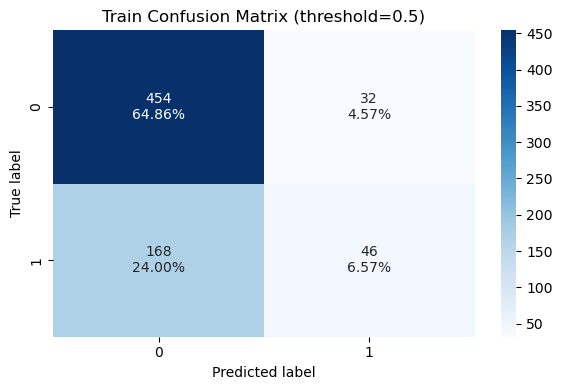

Training performance:


,Accuracy,Recall,Precision,F1 Score
0,0.714286,0.214953,0.589744,0.315068


In [27]:
# Training set performance at default threshold
plot_confusion_matrix(model, X_train, y_train, title="Train Confusion Matrix (threshold=0.5)")
log_reg_model_train_perf = model_performance_classification_sklearn(model, X_train, y_train)
print("Training performance:")
log_reg_model_train_perf

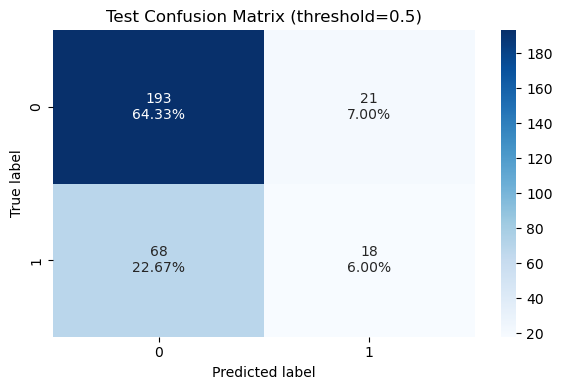

Test performance:


,Accuracy,Recall,Precision,F1 Score
0,0.703333,0.209302,0.461538,0.288


In [28]:
# Test set performance at default threshold
plot_confusion_matrix(model, X_test, y_test, title="Test Confusion Matrix (threshold=0.5)")
log_reg_model_test_perf = model_performance_classification_sklearn(model, X_test, y_test)
print("Test performance:")
log_reg_model_test_perf

### 6.2 ROC Curve & Optimal Threshold

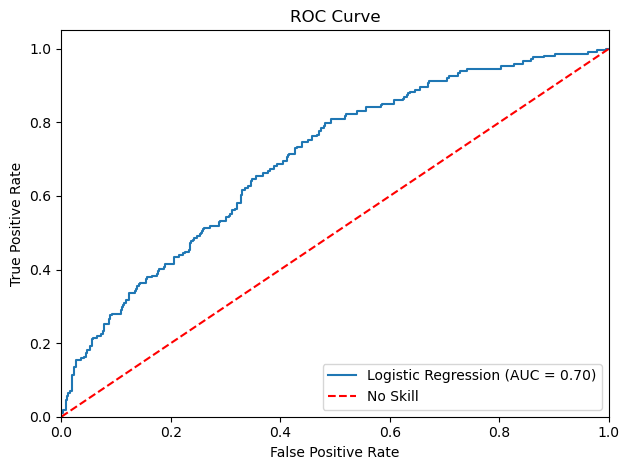

In [29]:
# Plot ROC curve — trade-off between True Positive Rate and False Positive Rate
logit_roc_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, model.predict_proba(X_train)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {logit_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "r--", label="No Skill")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [30]:
# Optimal ROC threshold: maximises (TPR - FPR) — Youden's J statistic
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(f"Optimal ROC threshold: {optimal_threshold_auc_roc:.4f}")

Optimal ROC threshold: 0.2549


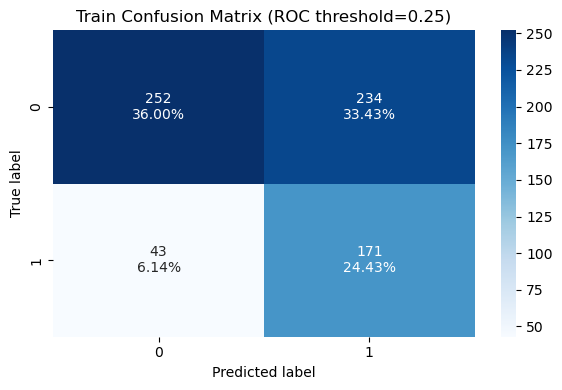

Training performance (ROC threshold):


,Accuracy,Recall,Precision,F1 Score
0,0.604286,0.799065,0.422222,0.552504


In [31]:
# Training performance at ROC-optimal threshold
plot_confusion_matrix(model, X_train, y_train,
                      threshold=optimal_threshold_auc_roc,
                      title=f"Train Confusion Matrix (ROC threshold={optimal_threshold_auc_roc:.2f})")
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_sklearn(
    model, X_train, y_train, threshold=optimal_threshold_auc_roc
)
print("Training performance (ROC threshold):")
log_reg_model_train_perf_threshold_auc_roc

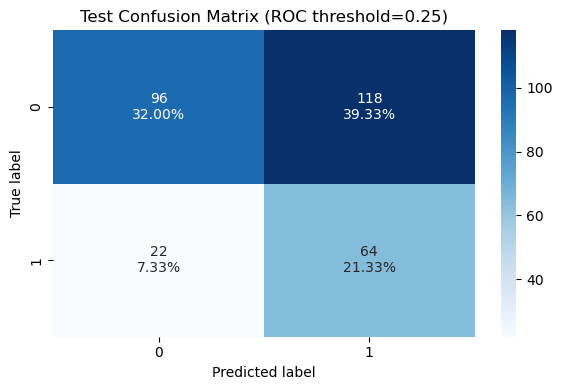

Test performance (ROC threshold):


,Accuracy,Recall,Precision,F1 Score
0,0.533333,0.744186,0.351648,0.477612


In [32]:
# Test performance at ROC-optimal threshold
plot_confusion_matrix(model, X_test, y_test,
                      threshold=optimal_threshold_auc_roc,
                      title=f"Test Confusion Matrix (ROC threshold={optimal_threshold_auc_roc:.2f})")
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_sklearn(
    model, X_test, y_test, threshold=optimal_threshold_auc_roc
)
print("Test performance (ROC threshold):")
log_reg_model_test_perf_threshold_auc_roc

### 6.3 Precision-Recall Curve & Optimal Threshold

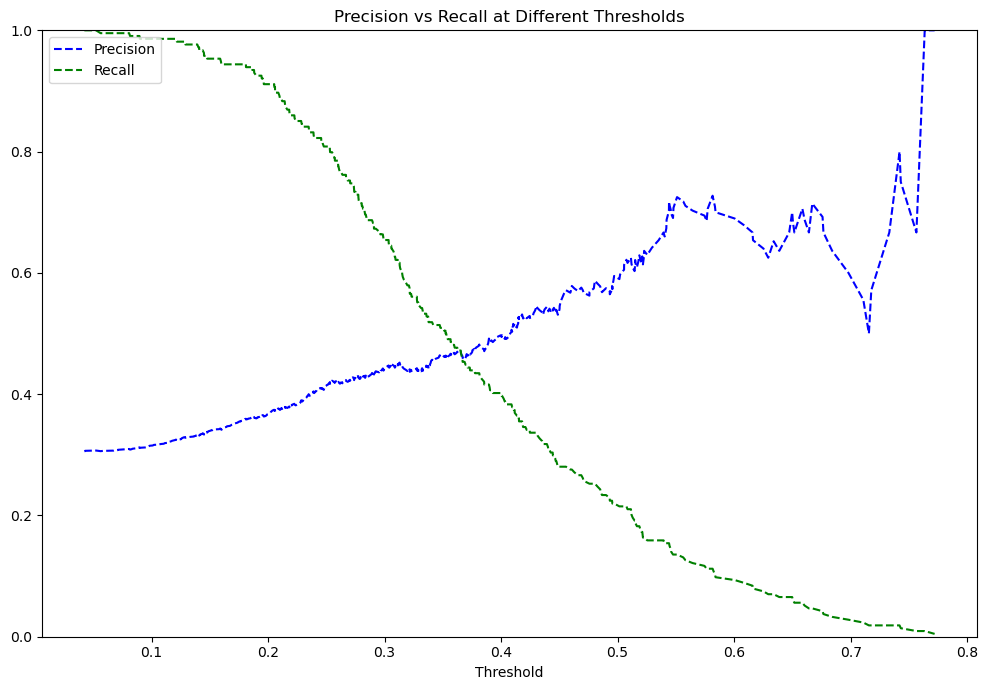

In [33]:
# Precision-Recall curve — especially useful under class imbalance
y_scores = model.predict_proba(X_train)[:, 1]
prec, rec, thres = precision_recall_curve(y_train, y_scores)

plt.figure(figsize=(10, 7))
plt.plot(thres, prec[:-1], "b--", label="Precision")
plt.plot(thres, rec[:-1],  "g--", label="Recall")
plt.xlabel("Threshold")
plt.title("Precision vs Recall at Different Thresholds")
plt.legend(loc="upper left")
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

In [34]:
# Optimal PR threshold: where precision equals recall (balanced F1)
idx = np.where((rec == prec) == True)[0][0]
optimal_threshold_prec_rec = thres[idx]
print(f"Optimal Precision-Recall threshold: {optimal_threshold_prec_rec:.4f}")

Optimal Precision-Recall threshold: 0.3655


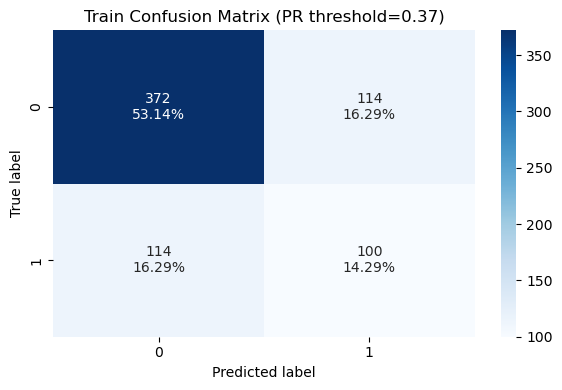

Training performance (PR threshold):


,Accuracy,Recall,Precision,F1 Score
0,0.674286,0.46729,0.46729,0.46729


In [35]:
# Training performance at PR-optimal threshold
plot_confusion_matrix(model, X_train, y_train,
                      threshold=optimal_threshold_prec_rec,
                      title=f"Train Confusion Matrix (PR threshold={optimal_threshold_prec_rec:.2f})")
log_reg_model_train_perf_threshold_curve = model_performance_classification_sklearn(
    model, X_train, y_train, threshold=optimal_threshold_prec_rec
)
print("Training performance (PR threshold):")
log_reg_model_train_perf_threshold_curve

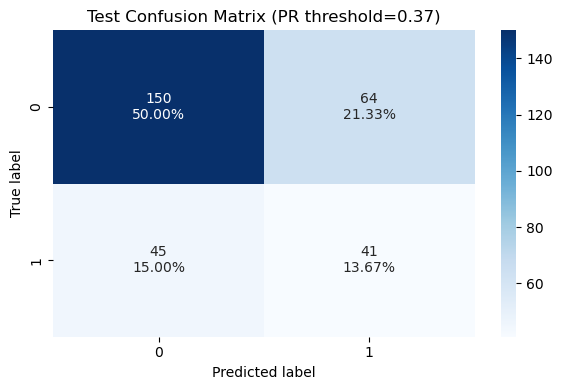

Test performance (PR threshold):


,Accuracy,Recall,Precision,F1 Score
0,0.636667,0.476744,0.390476,0.429319


In [36]:
# Test performance at PR-optimal threshold
plot_confusion_matrix(model, X_test, y_test,
                      threshold=optimal_threshold_prec_rec,
                      title=f"Test Confusion Matrix (PR threshold={optimal_threshold_prec_rec:.2f})")
log_reg_model_test_perf_threshold_curve = model_performance_classification_sklearn(
    model, X_test, y_test, threshold=optimal_threshold_prec_rec
)
print("Test performance (PR threshold):")
log_reg_model_test_perf_threshold_curve

## 7. Model Comparison — All Thresholds

In [37]:
# Compare all three threshold strategies on training set
models_train_comp_df = pd.concat(
    [log_reg_model_train_perf.T,
     log_reg_model_train_perf_threshold_auc_roc.T,
     log_reg_model_train_perf_threshold_curve.T],
    axis=1
)
models_train_comp_df.columns = [
    "Default (0.5)",
    f"ROC Optimal ({optimal_threshold_auc_roc:.2f})",
    f"PR Optimal ({optimal_threshold_prec_rec:.2f})",
]
print("Training Performance Comparison:")
models_train_comp_df

Training Performance Comparison:


,Default (0.5),ROC Optimal (0.25),PR Optimal (0.37)
Accuracy,0.714286,0.604286,0.674286
Recall,0.214953,0.799065,0.467290
Precision,0.589744,0.422222,0.467290
F1 Score,0.315068,0.552504,0.467290


In [38]:
# Compare all three threshold strategies on test set
models_test_comp_df = pd.concat(
    [log_reg_model_test_perf.T,
     log_reg_model_test_perf_threshold_auc_roc.T,
     log_reg_model_test_perf_threshold_curve.T],
    axis=1
)
models_test_comp_df.columns = [
    "Default (0.5)",
    f"ROC Optimal ({optimal_threshold_auc_roc:.2f})",
    f"PR Optimal ({optimal_threshold_prec_rec:.2f})",
]
print("Test Performance Comparison:")
models_test_comp_df

Test Performance Comparison:


,Default (0.5),ROC Optimal (0.25),PR Optimal (0.37)
Accuracy,0.703333,0.533333,0.636667
Recall,0.209302,0.744186,0.476744
Precision,0.461538,0.351648,0.390476
F1 Score,0.288000,0.477612,0.429319


## Conclusion: Threshold tuning via ROC and Precision-Recall curves is critical here — in credit risk, recall for "bad" cases matters more than raw accuracy. The ROC-optimal threshold offered the best balance.